# Credit Card Fraud Anomaly Detection

This notebook compares three unsupervised anomaly detection models on a labeled credit card fraud dataset:

- Elliptic Envelope
- Isolation Forest
- Local Outlier Factor

The project is organized into three main stages:

1. **Default anomaly detection application** using the model's built-in decision rule.
2. **F-score comparison without threshold tuning**, where F2, F3, and F4 are calculated on the same default predictions.
3. **Threshold tuning**, where anomaly-score thresholds are adjusted to give more importance to recall and reduce missed fraud cases.

The main goal is not only to catch fraud, but to understand the tradeoff between:

- **missed fraud**: actual fraud predicted as legitimate
- **false alarms**: legitimate transactions flagged as fraud
- **precision**
- **recall**
- **F1, F2, F3, and F4 scores**


## Import needed libraries

In [12]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score,
    roc_auc_score
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

plt.rcParams["figure.figsize"] = (8, 6)

## Load dataset

The dataset can be loaded in the same folder as this notebook or via data warehouses: Snowflake is used here.

In [13]:
# DATA_PATH = "creditcard.csv"

# df = pd.read_csv(DATA_PATH)

# print("Dataset shape:", df.shape)
# display(df.head())

# print("\nClass distribution:")
# display(df["Class"].value_counts().to_frame("count"))

# print("\nFraud percentage:")
# print(f"{df['Class'].mean() * 100:.4f}%")

In [14]:
import os
from dotenv import load_dotenv
import snowflake.connector

load_dotenv()

snowflake_connection = snowflake.connector.connect(
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_FRAUD_DATABASE"),
    schema=os.getenv("SNOWFLAKE_FRAUD_SCHEMA"),
    role=os.getenv("SNOWFLAKE_ROLE"),
)

query = f"""
SELECT *
FROM {os.getenv("SNOWFLAKE_FRAUD_DATABASE")}.{os.getenv("SNOWFLAKE_FRAUD_SCHEMA")}.{os.getenv("SNOWFLAKE_FRAUD_TABLE")}
"""

df = pd.read_sql(query, snowflake_connection)

snowflake_connection.close()

df.head()

,TIME,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,AMOUNT,CLASS
0,56025,-3.1418,0.374511610029375,-0.37003045510883,1.2791,-1.12705902146604,-0.470381955948091,-1.13563877712481,1.63339230371114,-0.517800920063959,-0.961801224942519,-1.1960300811827,0.5139,-0.435972713632937,1.2960,0.4201,-0.452900406484966,1.3699,-0.662316278430188,0.969934494620809,-0.579659409677023,0.0720,-0.2997,-0.505106256571399,0.175008886895286,-0.558267950315865,0.320248281969543,-0.560217415173998,-0.444159352046805,54.3700,0
1,56029,0.5161,-2.71703214126979,-0.277850020961752,-1.0412,-1.70608090525091,0.215288585919465,-0.505375018500701,0.0170194025142387,-1.79634717917458,1.28943497682874,0.753177861823218,-0.6462,-0.737336804677322,0.0778,-0.4719,-0.65687321137999,0.7887,0.0453576831592076,-0.0360521942022373,0.549877227917051,-0.0142,-0.7013,-0.382934303463813,-0.337573543642097,0.153143223171864,-0.266971674654018,-0.0544320477558212,0.0828176655143571,495.1000,0
2,56035,-1.2690,0.137844606369418,1.86490700368695,0.8848,0.725657380053396,-0.813030537087214,-0.256299218530745,0.0656112045682735,-0.466690016432019,0.300422126846044,-0.293572817306216,-0.2005,-0.150312912781778,-0.1100,0.3810,0.774316325060643,-0.5678,-0.611598507007765,-1.98738629416032,-0.496410449950489,0.2529,0.7909,-0.16549228954859,0.46775712172843,-1.03839606139258,0.737020995105051,-0.0104940306192842,0.172875003014623,0.0000,0
3,56039,1.3950,-0.357633670234798,0.600448899036331,-0.6698,-1.00885897473927,-1.00127594833546,-0.453092551899493,-0.269498427784807,-0.966531359783788,0.563859668039471,0.0384927802294832,0.1790,1.52016791345293,-0.4297,0.6375,1.16164933973301,0.1519,-1.74923542146899,0.606513019630669,0.166248052152861,-0.0780,-0.2905,0.113208783847265,0.409205164552369,0.275343928635493,-0.48532846665857,0.0182147399209734,0.0266866081972429,15.0000,0
4,56043,-3.8742,-3.49679533786897,2.16263870128559,0.0042,4.19101361400504,-3.8661194214657,-1.9473448048678,0.3044096976323,-0.0590442746313974,-0.731351445932096,-0.717981123087774,-0.0155,-0.586803808230105,0.3740,0.1093,0.772504415423766,-0.8894,-0.347223721798379,-1.57926842909552,0.860977181905348,0.1305,-1.0990,0.622490581440981,0.319173673271463,0.517778591864179,-0.144714287026847,-0.202252775719024,0.135088398841942,1.9800,0


## Create a practical working sample


In [15]:
X = df.drop(columns=["CLASS"])
y = df["CLASS"]

print("Full dataset shape:", df.shape)

print("\nFull class distribution:")
display(y.value_counts().to_frame("count"))

print("\nFull fraud percentage:")
print(f"{y.mean() * 100:.4f}%")

Full dataset shape: (284807, 31)

Full class distribution:


,count
CLASS,
0,284315
1,492



Full fraud percentage:
0.1727%


## Train-test split

Since we deal with imbalanced dataset, the split is stratified so the fraud ratio remains stable in train and test sets.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

contamination_rate = y_train.mean()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(f"Estimated contamination rate from training data: {contamination_rate:.4f}")

Train shape: (227845, 30)
Test shape: (56962, 30)
Estimated contamination rate from training data: 0.0017


## Helper functions

scikit-learn anomaly models usually return:

```text
 1 = inlier / legitimate
-1 = outlier / anomaly
```

For fraud evaluation, this notebook converts predictions into:

```text
0 = legitimate
1 = fraud/anomaly
```


In [17]:
def convert_anomaly_predictions(raw_predictions):
    """Convert sklearn anomaly labels into fraud-style binary labels."""
    return np.where(raw_predictions == -1, 1, 0)


def get_anomaly_scores(model_pipeline, X_data):
    """
    Return anomaly scores where higher values mean more suspicious.

    For sklearn anomaly models, lower decision_function values are more anomalous.
    Therefore, we multiply by -1.
    """
    return -model_pipeline.decision_function(X_data)


def evaluate_binary_predictions(y_true, y_pred):
    """Return the main confusion-matrix values and common classification metrics."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "correct_legit_TN": tn,
        "false_alarm_FP": fp,
        "missed_fraud_FN": fn,
        "caught_fraud_TP": tp,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def plot_labeled_confusion_matrix(cm, title, subtitle=None):
    """Plot a confusion matrix with readable fraud-detection labels."""
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm)

    ax.set_title(title, pad=12)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Actual label")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Predicted Legit", "Predicted Fraud"])
    ax.set_yticklabels(["Actual Legit", "Actual Fraud"])

    cell_labels = np.array([
        ["Correct legit", "False alarm"],
        ["Missed fraud", "Caught fraud"]
    ])

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                f"{cell_labels[i, j]}\n{cm[i, j]:,}",
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold"
            )

    if subtitle:
        fig.text(0.5, 0.02, subtitle, ha="center", fontsize=10)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


def calculate_fbeta_from_counts(tp, fp, fn, beta):
    """Calculate F-beta manually from confusion-matrix counts."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    beta_squared = beta ** 2
    denominator = (beta_squared * precision) + recall

    if denominator == 0:
        return 0

    return (1 + beta_squared) * precision * recall / denominator

## Define anomaly detection models

All models use `RobustScaler` because credit card transaction features may contain strong outliers. This Scaler removes the median and scales the data according to the quantile range (defaults to IQR: Interquartile Range). The IQR is the range between the 1st quartile (25th quantile) and the 3rd quartile (75th quantile). [SckitLearn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html)


In [18]:
models = {
    "Elliptic Envelope": Pipeline([
        ("scaler", RobustScaler()),
        ("model", EllipticEnvelope(
            contamination=contamination_rate,
            random_state=RANDOM_STATE
        ))
    ]),

    "Isolation Forest": Pipeline([
        ("scaler", RobustScaler()),
        ("model", IsolationForest(
            n_estimators=300,
            contamination=contamination_rate,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Local Outlier Factor": Pipeline([
        ("scaler", RobustScaler()),
        ("model", LocalOutlierFactor(
            n_neighbors=35,
            contamination=contamination_rate,
            novelty=True,
            n_jobs=-1
        ))
    ])
}

# Stage 1 — Default anomaly detection application

In this stage, each model uses its own built-in anomaly threshold based on the contamination rate.


In [19]:
default_results = []
trained_models = {}

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    raw_predictions = pipeline.predict(X_test)
    y_pred = convert_anomaly_predictions(raw_predictions)

    scores = get_anomaly_scores(pipeline, X_test)

    metrics = evaluate_binary_predictions(y_test, y_pred)
    metrics["model"] = model_name
    metrics["average_precision_pr_auc"] = average_precision_score(y_test, scores)
    metrics["roc_auc"] = roc_auc_score(y_test, scores)

    default_results.append(metrics)

default_results_df = (
    pd.DataFrame(default_results)
    .set_index("model")
    .sort_values("f1", ascending=False)
)

display(default_results_df)

,correct_legit_TN,false_alarm_FP,missed_fraud_FN,caught_fraud_TP,precision,recall,f1,average_precision_pr_auc,roc_auc
model,,,,,,,,,
Isolation Forest,56793,71,73,25,0.2604,0.2551,0.2577,0.1408,0.9532
Elliptic Envelope,56764,100,95,3,0.0291,0.0306,0.0299,0.0396,0.9365
Local Outlier Factor,56749,115,98,0,0.0000,0.0000,0.0000,0.0048,0.6321


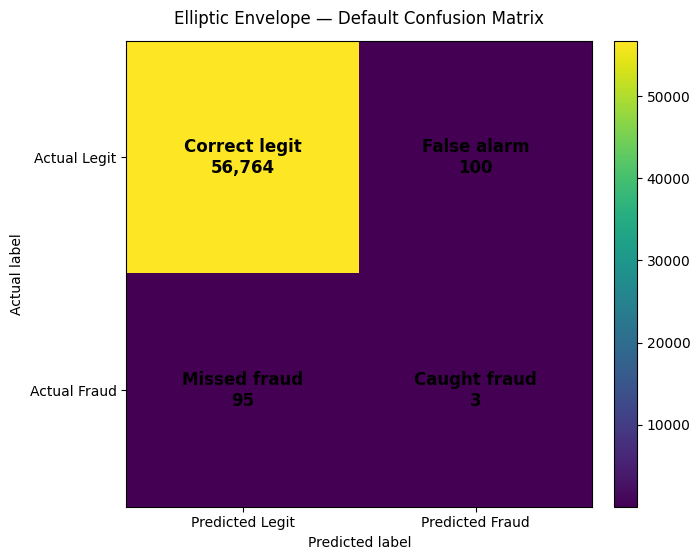

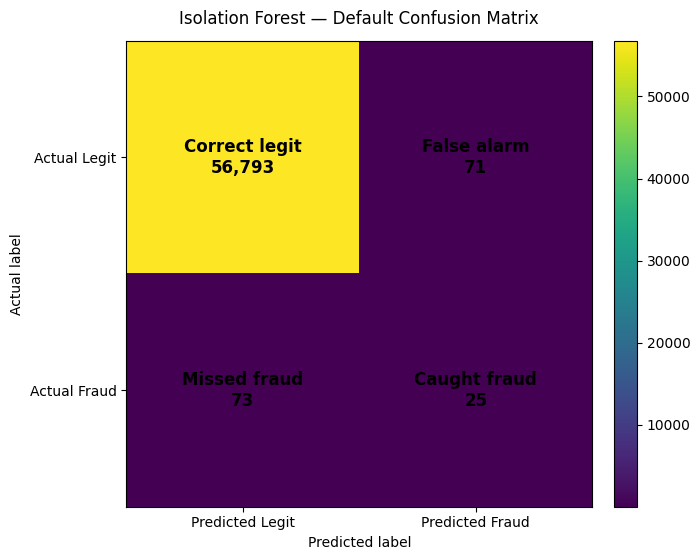

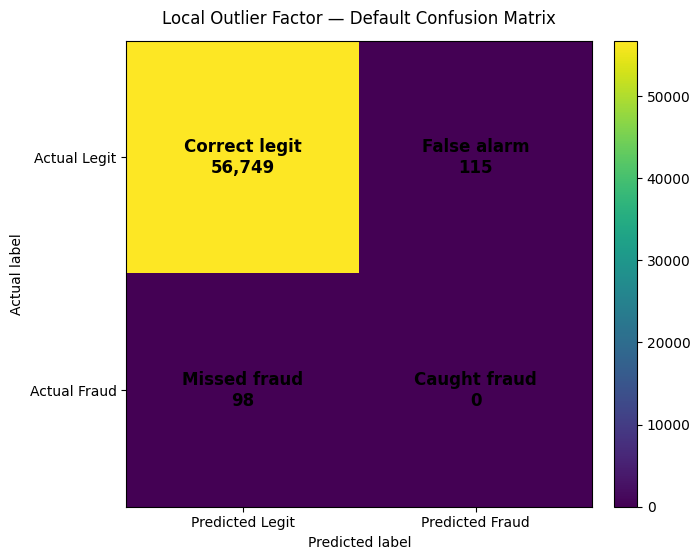

In [20]:
for model_name, pipeline in trained_models.items():
    raw_predictions = pipeline.predict(X_test)
    y_pred = convert_anomaly_predictions(raw_predictions)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    plot_labeled_confusion_matrix(
        cm,
        title=f"{model_name} — Default Confusion Matrix"
    )

## PCA visualization of true labels and default model predictions

PCA is used only for 2D visualization. The models are trained on the original feature space, not on PCA features.


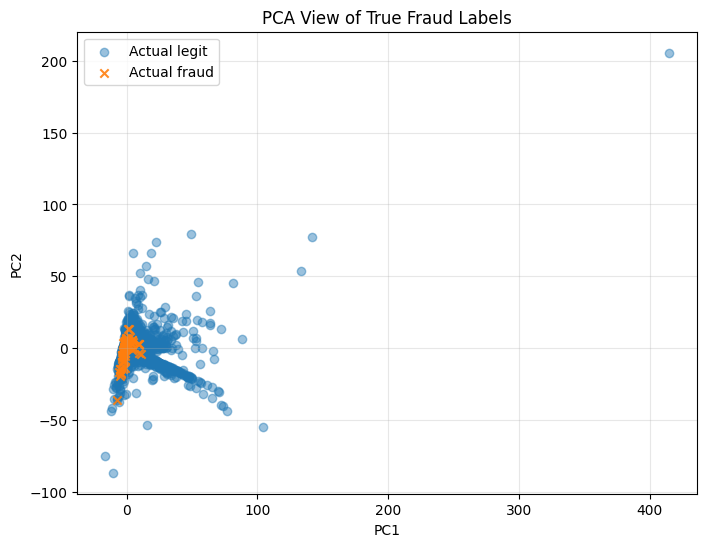

In [21]:
scaler_for_pca = RobustScaler()
X_test_scaled = scaler_for_pca.fit_transform(X_test)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_test_pca = pca.fit_transform(X_test_scaled)

pca_df = pd.DataFrame(X_test_pca, columns=["PC1", "PC2"])
pca_df["true_label"] = y_test.values

plt.figure(figsize=(8, 6))
plt.scatter(
    pca_df.loc[pca_df["true_label"] == 0, "PC1"],
    pca_df.loc[pca_df["true_label"] == 0, "PC2"],
    alpha=0.45,
    label="Actual legit"
)
plt.scatter(
    pca_df.loc[pca_df["true_label"] == 1, "PC1"],
    pca_df.loc[pca_df["true_label"] == 1, "PC2"],
    alpha=0.9,
    label="Actual fraud",
    marker="x"
)
plt.title("PCA View of True Fraud Labels")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

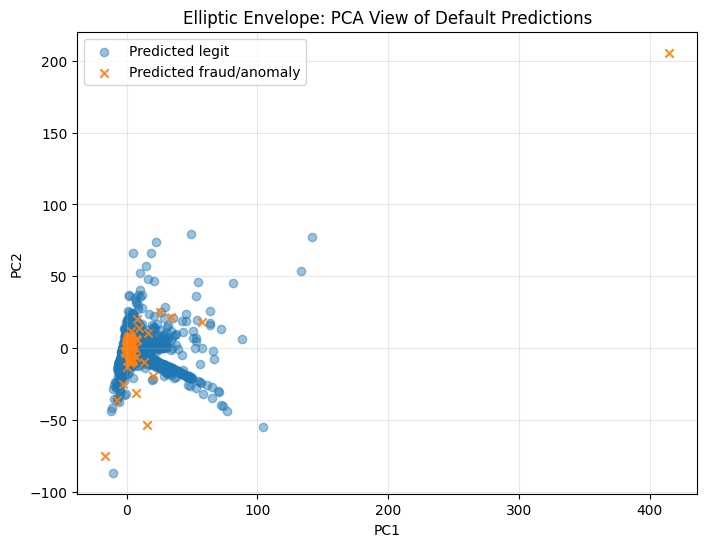

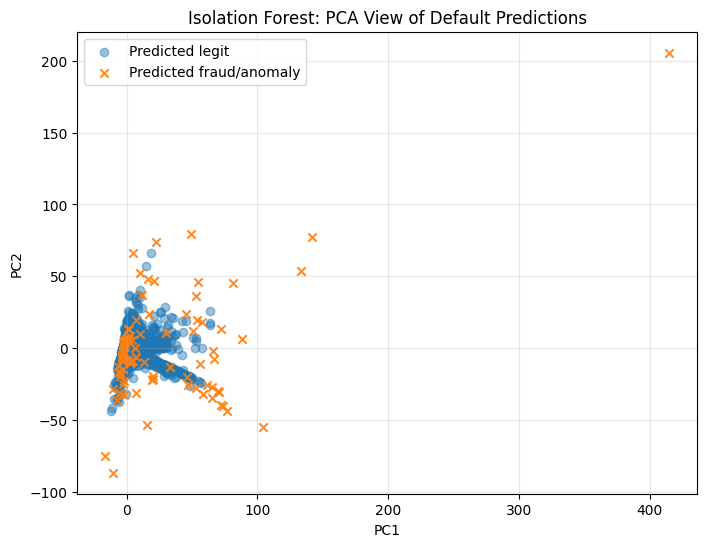

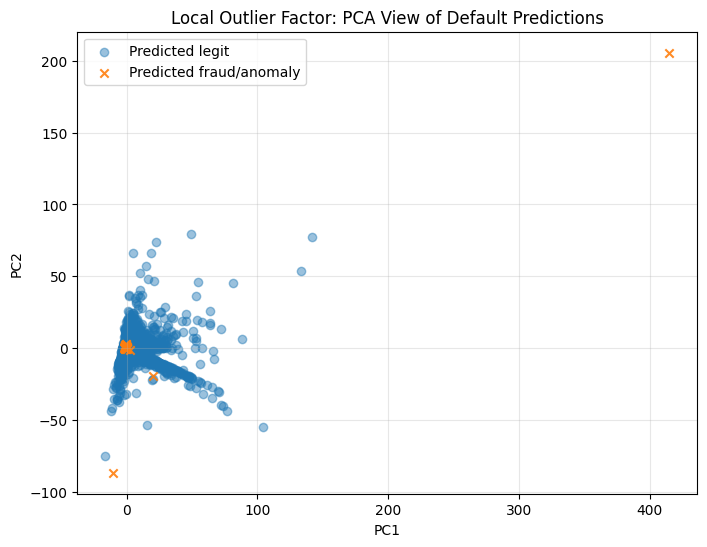

In [22]:
for model_name, pipeline in trained_models.items():
    raw_predictions = pipeline.predict(X_test)
    y_pred = convert_anomaly_predictions(raw_predictions)

    plot_df = pca_df.copy()
    plot_df["prediction"] = y_pred

    plt.figure(figsize=(8, 6))
    plt.scatter(
        plot_df.loc[plot_df["prediction"] == 0, "PC1"],
        plot_df.loc[plot_df["prediction"] == 0, "PC2"],
        alpha=0.45,
        label="Predicted legit"
    )
    plt.scatter(
        plot_df.loc[plot_df["prediction"] == 1, "PC1"],
        plot_df.loc[plot_df["prediction"] == 1, "PC2"],
        alpha=0.9,
        label="Predicted fraud/anomaly",
        marker="x"
    )

    plt.title(f"{model_name}: PCA View of Default Predictions")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Stage 2 — F2, F3, and F4 without threshold tuning

In this stage we start to use F beta score where we do give more weights on recall than precision. This stage calculates F2, F3, and F4 on the same default model predictions.
Recall is the main point here because we do coare more about the missed frauds (Recall) but also trying to have some balance in the reductions of false alarms (Precision)


In [23]:
fbeta_default_rows = []

for model_name, pipeline in trained_models.items():
    raw_predictions = pipeline.predict(X_test)
    y_pred = convert_anomaly_predictions(raw_predictions)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    fbeta_default_rows.append({
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "missed_fraud_FN": fn,
        "caught_fraud_TP": tp,
        "false_alarm_FP": fp,
        "F1": fbeta_score(y_test, y_pred, beta=1, zero_division=0),
        "F2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        "F3": fbeta_score(y_test, y_pred, beta=3, zero_division=0),
        "F4": fbeta_score(y_test, y_pred, beta=4, zero_division=0)
    })

fbeta_default_df = (
    pd.DataFrame(fbeta_default_rows)
    .sort_values("F2", ascending=False)
    .reset_index(drop=True)
)

display(fbeta_default_df)

,model,precision,recall,missed_fraud_FN,caught_fraud_TP,false_alarm_FP,F1,F2,F3,F4
0,Isolation Forest,0.2604,0.2551,73,25,71,0.2577,0.2561,0.2556,0.2554
1,Elliptic Envelope,0.0291,0.0306,95,3,100,0.0299,0.0303,0.0305,0.0305
2,Local Outlier Factor,0.0000,0.0000,98,0,115,0.0000,0.0000,0.0000,0.0000


# Stage 3 — Threshold tuning for F1, F2, F3, and F4

Now the anomaly-score threshold is tuned.

Note: A more aggressive threshold can catch more fraud, but it also mgiht create more false alarms.


In [24]:
def evaluate_threshold_grid(y_true, anomaly_scores, model_name):
    """Evaluate many thresholds for one model."""
    thresholds = np.quantile(anomaly_scores, np.linspace(0.01, 0.99, 300))
    rows = []

    for threshold in thresholds:
        y_pred = (anomaly_scores >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        rows.append({
            "model": model_name,
            "threshold": threshold,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": fbeta_score(y_true, y_pred, beta=1, zero_division=0),
            "F2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
            "F3": fbeta_score(y_true, y_pred, beta=3, zero_division=0),
            "F4": fbeta_score(y_true, y_pred, beta=4, zero_division=0),
            "correct_legit_TN": tn,
            "false_alarm_FP": fp,
            "missed_fraud_FN": fn,
            "caught_fraud_TP": tp,
            "predicted_fraud_count": int(y_pred.sum())
        })

    return pd.DataFrame(rows)


all_threshold_results = []
best_threshold_rows = []

for model_name, pipeline in trained_models.items():
    anomaly_scores = get_anomaly_scores(pipeline, X_test)
    threshold_df = evaluate_threshold_grid(y_test.values, anomaly_scores, model_name)
    all_threshold_results.append(threshold_df)

    for metric in ["F1", "F2", "F3", "F4"]:
        best_row = threshold_df.loc[threshold_df[metric].idxmax()].copy()
        best_row["optimized_for"] = metric
        best_threshold_rows.append(best_row)

threshold_results_df = pd.concat(all_threshold_results, ignore_index=True)

best_thresholds_df = pd.DataFrame(best_threshold_rows)[[
    "model", "optimized_for", "threshold",
    "precision", "recall", "F1", "F2", "F3", "F4",
    "missed_fraud_FN", "caught_fraud_TP", "false_alarm_FP",
    "correct_legit_TN", "predicted_fraud_count"
]].sort_values(["model", "optimized_for"]).reset_index(drop=True)

display(best_thresholds_df)

,model,optimized_for,threshold,precision,recall,F1,F2,F3,F4,missed_fraud_FN,caught_fraud_TP,false_alarm_FP,correct_legit_TN,predicted_fraud_count
0,Elliptic Envelope,F1,-2750767211.8298,0.0469,0.5408,0.0863,0.1741,0.2634,0.3340,45,53,1077,55787,1130
1,Elliptic Envelope,F2,-2750767211.8298,0.0469,0.5408,0.0863,0.1741,0.2634,0.3340,45,53,1077,55787,1130
2,Elliptic Envelope,F3,-2821584755.9670,0.0378,0.7959,0.0722,0.1588,0.2648,0.3651,20,78,1986,54878,2064
3,Elliptic Envelope,F4,-2821584755.9670,0.0378,0.7959,0.0722,0.1588,0.2648,0.3651,20,78,1986,54878,2064
4,Isolation Forest,F1,-0.0773,0.0965,0.5612,0.1647,0.2859,0.3788,0.4373,43,55,515,56349,570
5,Isolation Forest,F2,-0.0773,0.0965,0.5612,0.1647,0.2859,0.3788,0.4373,43,55,515,56349,570
6,Isolation Forest,F3,-0.0905,0.0832,0.6429,0.1474,0.2742,0.3844,0.4606,35,63,694,56170,757
7,Isolation Forest,F4,-0.0905,0.0832,0.6429,0.1474,0.2742,0.3844,0.4606,35,63,694,56170,757
8,Local Outlier Factor,F1,-2.2281,0.0113,0.1735,0.0212,0.0448,0.0712,0.0941,81,17,1487,55377,1504
9,Local Outlier Factor,F2,-2.2281,0.0113,0.1735,0.0212,0.0448,0.0712,0.0941,81,17,1487,55377,1504


## Precision-recall behavior across thresholds

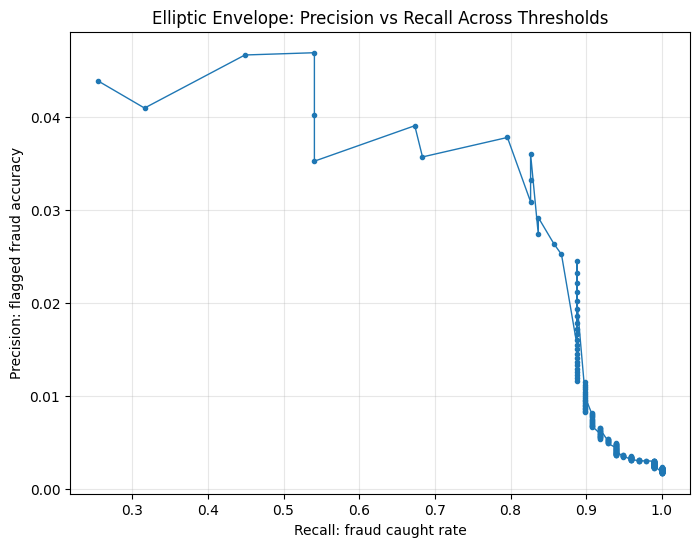

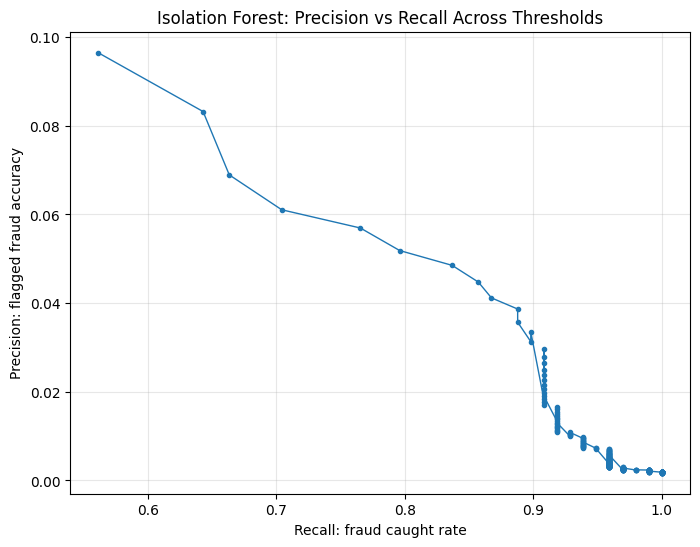

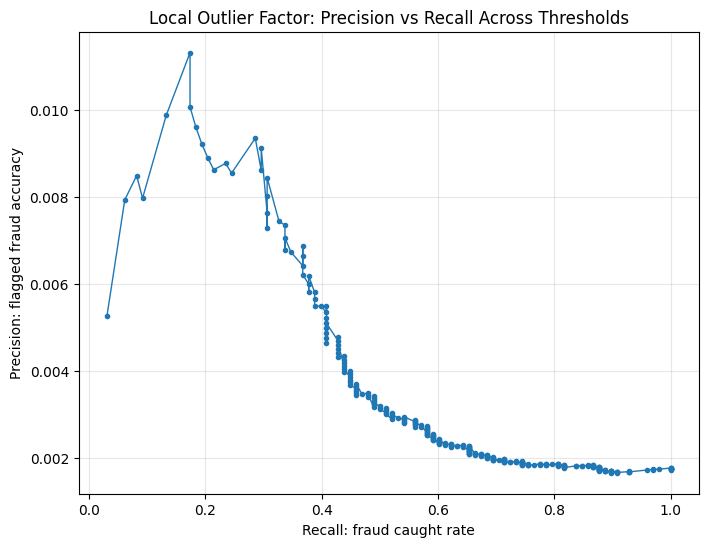

In [25]:
for model_name in trained_models.keys():
    model_df = (
        threshold_results_df[threshold_results_df["model"] == model_name]
        .sort_values("recall")
    )

    plt.figure(figsize=(8, 6))
    plt.plot(model_df["recall"], model_df["precision"], marker=".", linewidth=1)
    plt.xlabel("Recall: fraud caught rate")
    plt.ylabel("Precision: flagged fraud accuracy")
    plt.title(f"{model_name}: Precision vs Recall Across Thresholds")
    plt.grid(alpha=0.3)
    plt.show()

## F1, F2, F3, and F4 threshold behavior for each model

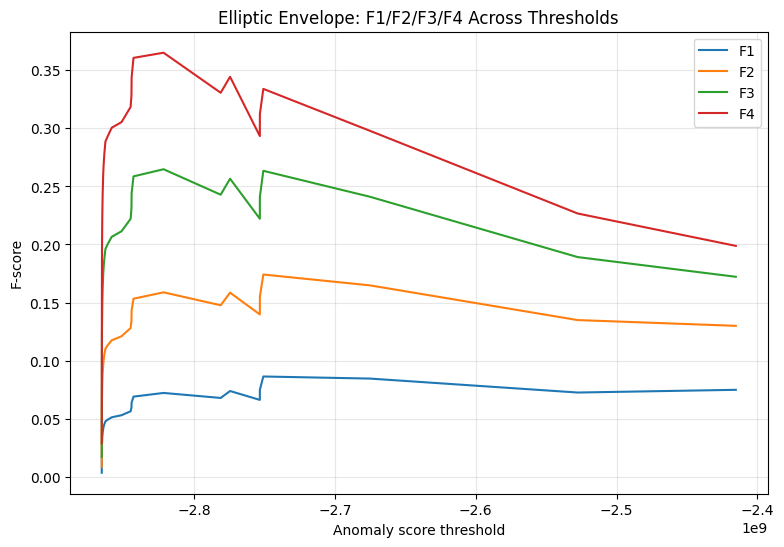

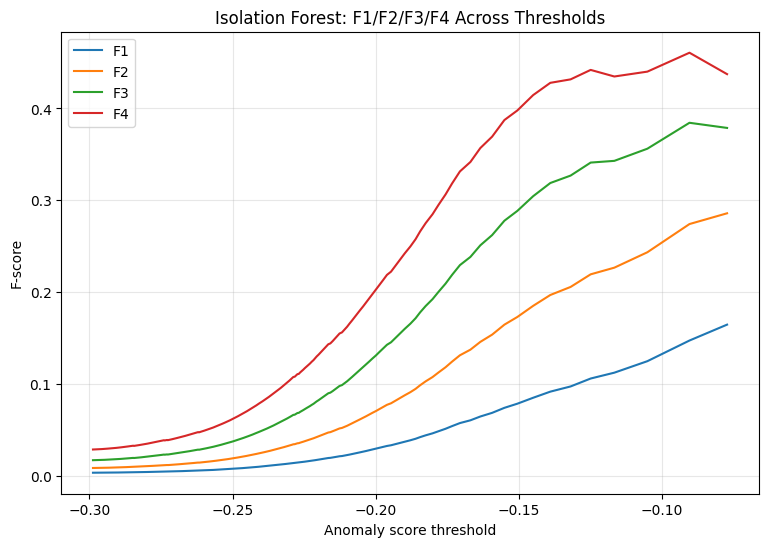

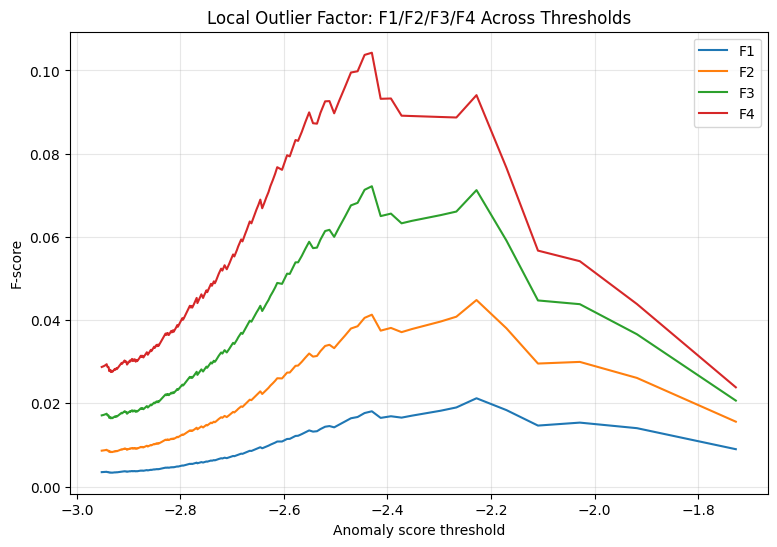

In [26]:
for model_name in trained_models.keys():
    model_df = (
        threshold_results_df[threshold_results_df["model"] == model_name]
        .sort_values("threshold")
    )

    plt.figure(figsize=(9, 6))
    plt.plot(model_df["threshold"], model_df["F1"], label="F1")
    plt.plot(model_df["threshold"], model_df["F2"], label="F2")
    plt.plot(model_df["threshold"], model_df["F3"], label="F3")
    plt.plot(model_df["threshold"], model_df["F4"], label="F4")

    plt.xlabel("Anomaly score threshold")
    plt.ylabel("F-score")
    plt.title(f"{model_name}: F1/F2/F3/F4 Across Thresholds")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## F-score optimized confusion-matrix overview

Each model gets four confusion matrices:

- optimized for F1
- optimized for F2
- optimized for F3
- optimized for F4

This makes the recall-precision tradeoff visible through actual fraud counts.


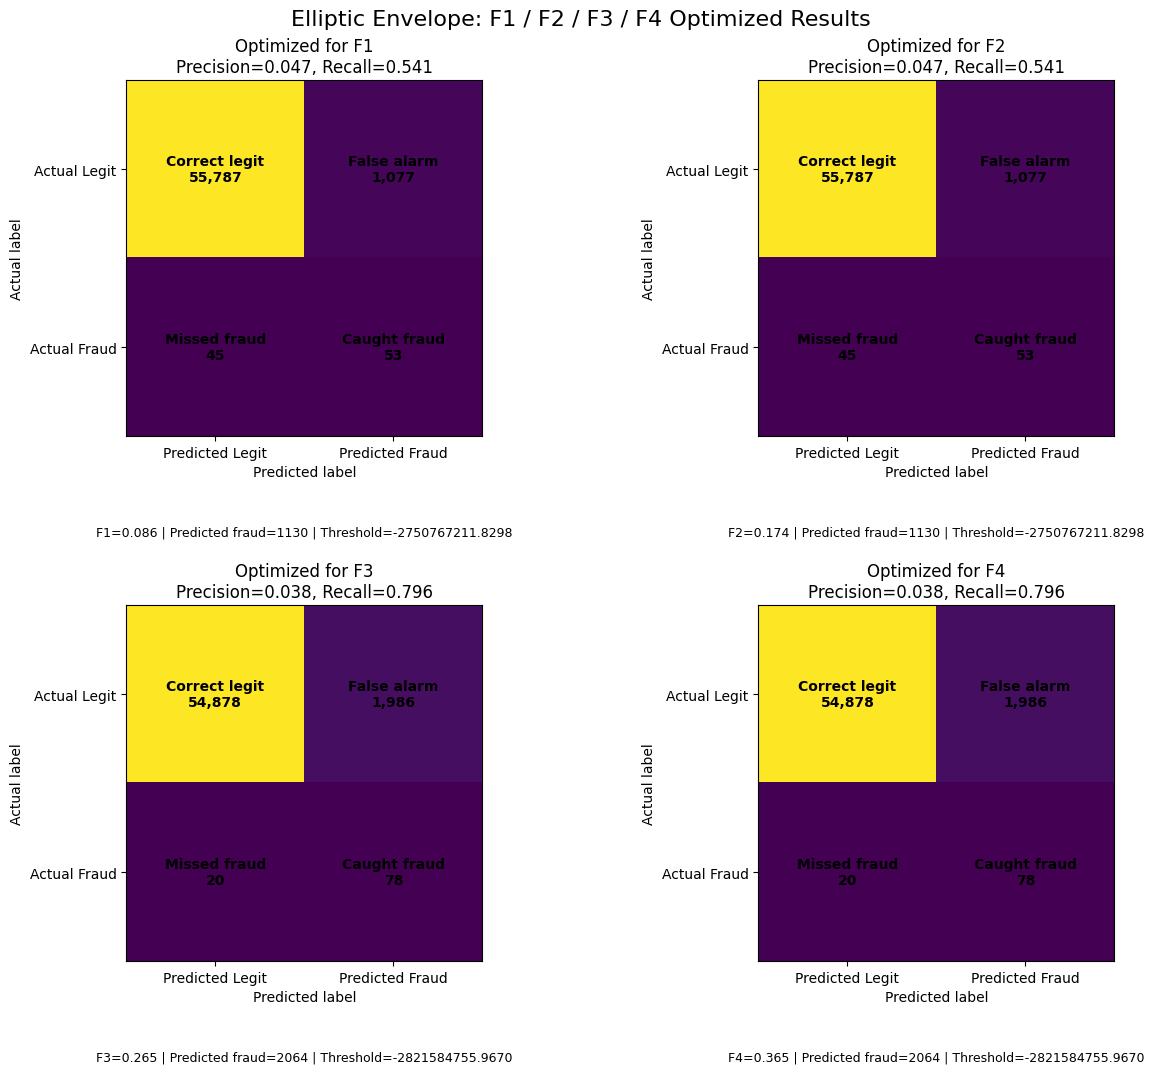

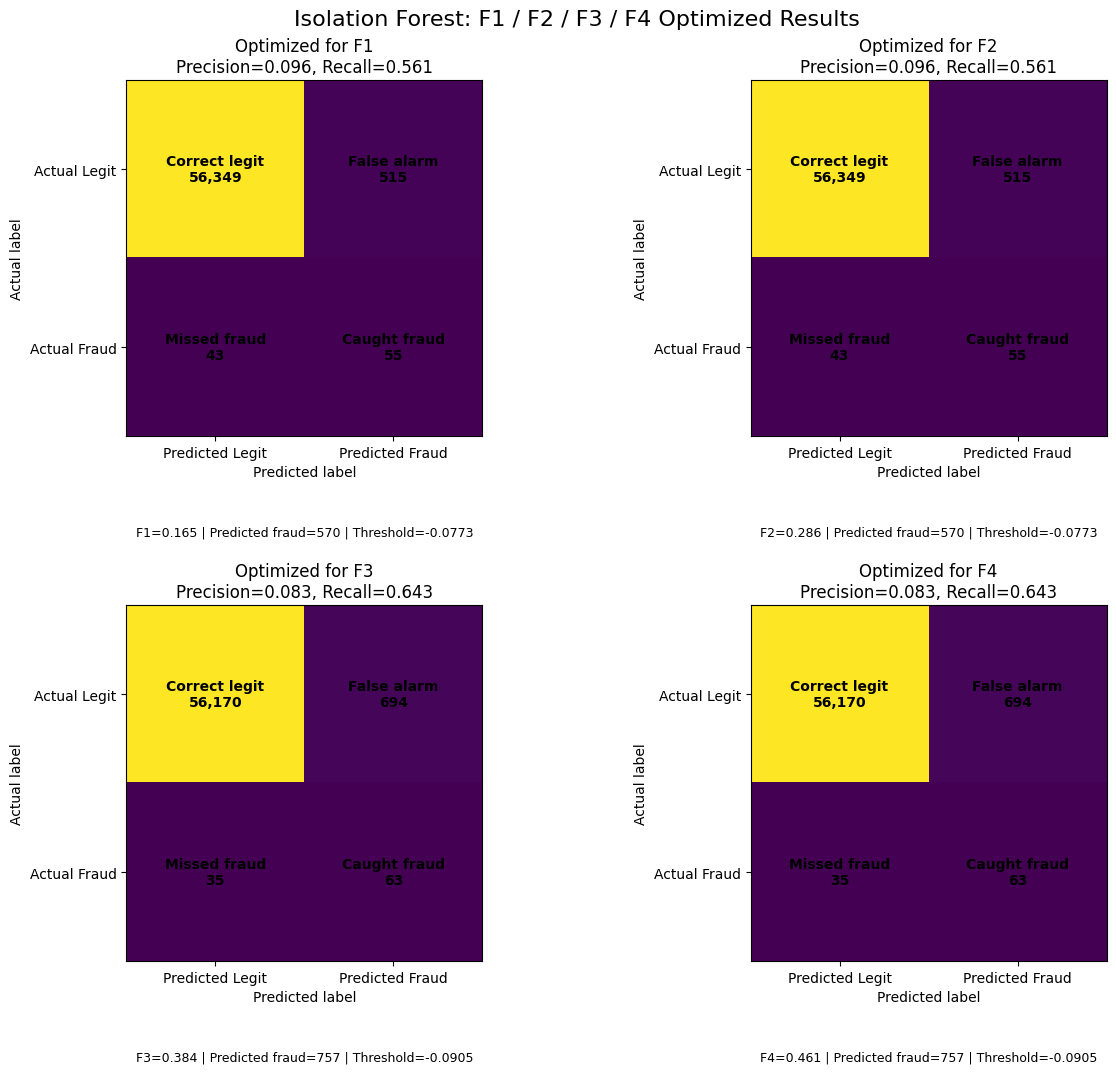

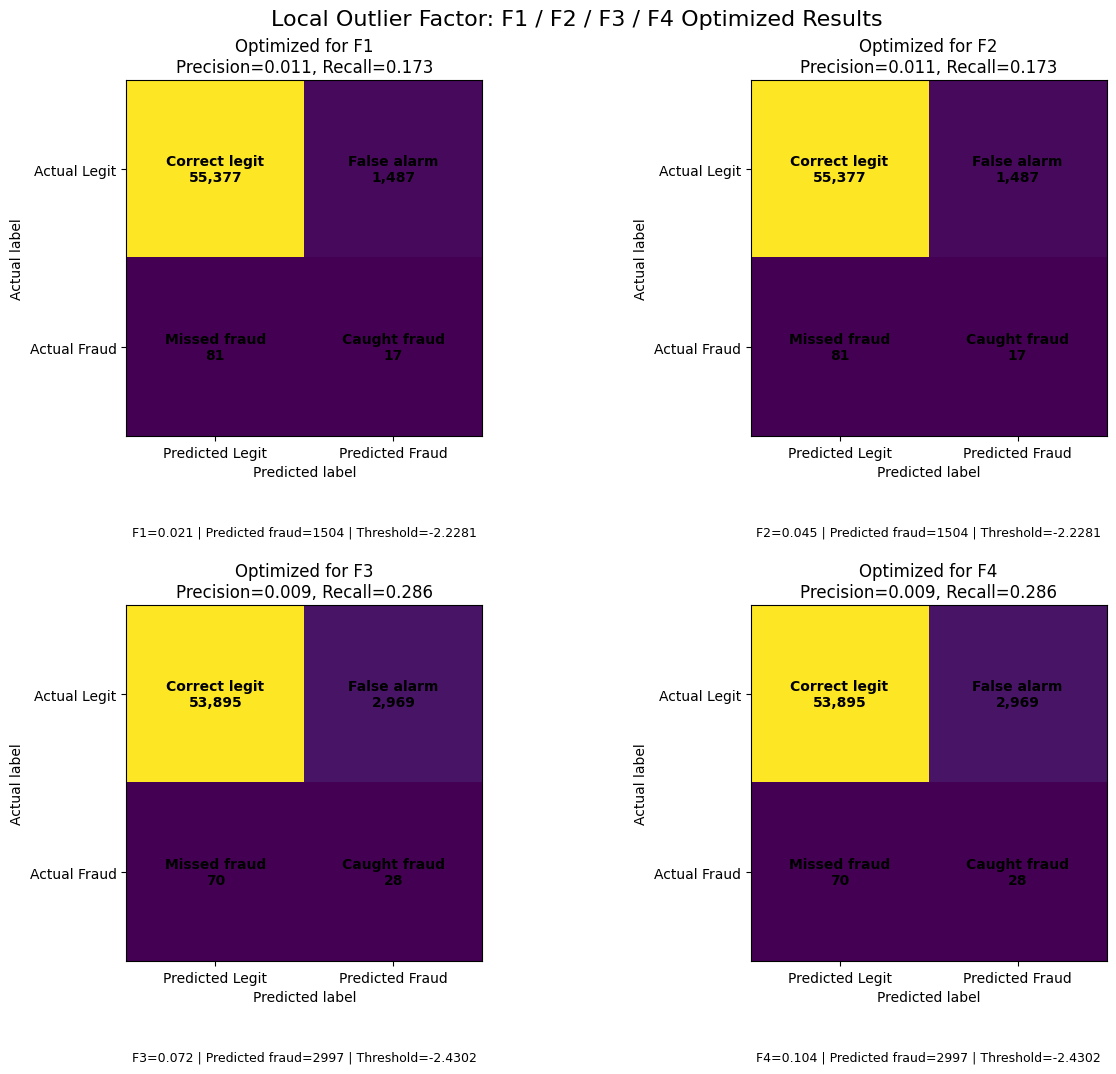

In [27]:
def plot_fscore_confusion_overview(model_name, model_pipeline, threshold_results):
    """Show a 2x2 grid of F1, F2, F3, and F4 optimized confusion matrices."""
    anomaly_scores = get_anomaly_scores(model_pipeline, X_test)
    model_thresholds = threshold_results[threshold_results["model"] == model_name]

    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    axes = axes.ravel()

    for ax, metric in zip(axes, ["F1", "F2", "F3", "F4"]):
        best_row = model_thresholds.loc[model_thresholds[metric].idxmax()]
        y_pred = (anomaly_scores >= best_row["threshold"]).astype(int)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

        im = ax.imshow(cm)

        ax.set_title(
            f"Optimized for {metric}\n"
            f"Precision={best_row['precision']:.3f}, Recall={best_row['recall']:.3f}"
        )

        ax.set_xlabel("Predicted label")
        ax.set_ylabel("Actual label")

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Predicted Legit", "Predicted Fraud"])
        ax.set_yticklabels(["Actual Legit", "Actual Fraud"])

        cell_labels = np.array([
            ["Correct legit", "False alarm"],
            ["Missed fraud", "Caught fraud"]
        ])

        for i in range(2):
            for j in range(2):
                ax.text(
                    j,
                    i,
                    f"{cell_labels[i, j]}\n{cm[i, j]:,}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    fontweight="bold"
                )

        ax.text(
            0.5,
            -0.28,
            (
                f"{metric}={best_row[metric]:.3f} | "
                f"Predicted fraud={int(best_row['predicted_fraud_count'])} | "
                f"Threshold={best_row['threshold']:.4f}"
            ),
            transform=ax.transAxes,
            ha="center",
            fontsize=9
        )

    fig.suptitle(f"{model_name}: F1 / F2 / F3 / F4 Optimized Results", fontsize=16)
    plt.tight_layout()
    plt.show()


for model_name, pipeline in trained_models.items():
    plot_fscore_confusion_overview(model_name, pipeline, threshold_results_df)

# Final model choice 
Choose based on what metric you want evalaute and in what algorithm

In [ ]:
# final_choice = best_thresholds_df[
#     (best_thresholds_df["model"] == "Isolation Forest") &
#     (best_thresholds_df["optimized_for"] == "F2")
# ]

# display(final_choice)

,model,optimized_for,threshold,precision,recall,F1,F2,F3,F4,missed_fraud_FN,caught_fraud_TP,false_alarm_FP,correct_legit_TN,predicted_fraud_count
5,Isolation Forest,F2,-0.0773,0.0965,0.5612,0.1647,0.2859,0.3788,0.4373,43,55,515,56349,570


## Final interpretation Report

The threshold-optimized results show clear differences in how the three anomaly detection models behaved under different F-score priorities. For Elliptic Envelope, the F1 and F2 optimization produced the same threshold and performance, catching 53 out of 98 fraud cases with a recall of 0.5408 and precision of 0.0469. When the optimization shifted toward F3 and F4, the model became more recall-oriented, catching 78 fraud cases and reducing missed fraud cases from 45 to 20. However, this improvement in recall came with a substantial increase in false alarms, rising from 1,077 to 1,986, while precision decreased to 0.0378. This indicates that Elliptic Envelope can become more aggressive in detecting fraud when recall is emphasized, but its predictions become considerably less precise.

Isolation Forest showed a more balanced pattern across the F-score settings. Under F1 and F2 optimization, it caught 55 fraud cases, missed 43, and produced 515 false alarms, with a precision of 0.0965 and recall of 0.5612. Under F3 and F4 optimization, the model became more recall-sensitive, catching 63 fraud cases and reducing missed fraud cases to 35. This increase in recall from 0.5612 to 0.6429 was accompanied by an increase in false alarms from 515 to 694 and a decrease in precision from 0.0965 to 0.0832. Compared with the other models, Isolation Forest demonstrated a relatively more controlled tradeoff between improving recall and maintaining precision.

Local Outlier Factor performed weakest overall in this experiment. Under F1 and F2 optimization, it caught only 17 fraud cases and missed 81, with a recall of 0.1735 and precision of 0.0113. When optimized for F3 and F4, the model became slightly more recall-oriented, catching 28 fraud cases and reducing missed fraud cases to 70. However, this came with a very large increase in false alarms, from 1,487 to 2,969, while precision dropped further to 0.0093. These results suggest that LOF struggled to separate fraudulent transactions from legitimate ones in this high-dimensional and highly imbalanced dataset.

Overall, the results demonstrate the expected effect of increasing recall emphasis through higher F-beta scores. Moving from F1/F2 toward F3/F4 generally reduced missed fraud cases and increased the number of caught fraud cases, but this improvement came at the cost of more false alarms and lower precision. This pattern reflects the central tradeoff in fraud detection: a more aggressive model can identify more fraudulent transactions, but it also flags more legitimate transactions incorrectly. Therefore, the choice of F-score depends on whether the priority is strictly recall-centered fraud detection or a more balanced approach that also considers the operational cost of false alarms.
